## ANALYSIS - EXPLORATORY DATA ANALYSIS & BUSINESS INSIGHTS

Notebook này tập trung vào việc thực hiện:

- Phân tích Khám phá Dữ liệu (EDA) chuyên sâu nhằm giải mã bài toán cốt lõi của doanh nghiệp. 
- Xác định các tác nhân gây ra tình trạng biên lợi nhuận (Margin) âm mặc dù quy mô doanh thu duy trì ở mức cao.
- Mục tiêu cuối cùng là trích xuất các đặc trưng (features) quan trọng để cung cấp cho các giai đoạn tiền xử lý và huấn luyện mô hình học máy tiếp theo.

Chúng tôi tiếp cận bài toán thông qua 5 trụ cột phân tích trọng tâm:
1. Financial Health & Macro Trends: Đánh giá tương quan giữa tăng trưởng doanh thu và hiệu suất sinh lời qua các giai đoạn.

2. Discount Dependency Analysis: Định lượng mức độ lệ thuộc vào các chương trình khuyến mãi và tác động của chúng tới dòng tiền.

3. Product Portfolio Performance: Phân loại danh mục sản phẩm theo quy tắc Pareto 80/20 và xác định các nhóm hàng "ngôi sao" có biên lợi nhuận cao (nhóm Standard).

4. Customer Persona & Lifecycle: Phân tích hành vi mua sắm theo nhân khẩu học (đặc biệt là nhóm 55+) và chu kỳ tái mua hàng (175 ngày).

5. Operational & Channel Efficiency: Nhận diện các điểm nghẽn vận hành (trả hàng, hủy đơn) và hiệu quả chuyển đổi theo từng kênh (Email, Region).

**Mục lục**:
1. [Thiết lập và cài đặt](#1)
2. [Triển khai & Trực quan hóa](#2)
3. [Kết luận & Đề xuất đặc trưng](#3)

<a id="1"></a>

## 1. Thiết lập và cài đặt
Nhập các thư viện cần thiết và kết nối database `datathon.duckdb`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys, os
sys.path.append(os.path.abspath('..'))
from src.connection import get_connection

In [2]:
conn = get_connection()

[OKE] Kết nối thành công tới database tại C:\Users\YOGA\Desktop\MyProjects\datathon\github\vimchanhxa-datathon\data\database\datathon.duckdb


<a id="1"></a>

## 2. Triển khai & Trực quan hóa


## 2.1 Revenue vs. Margin Trends

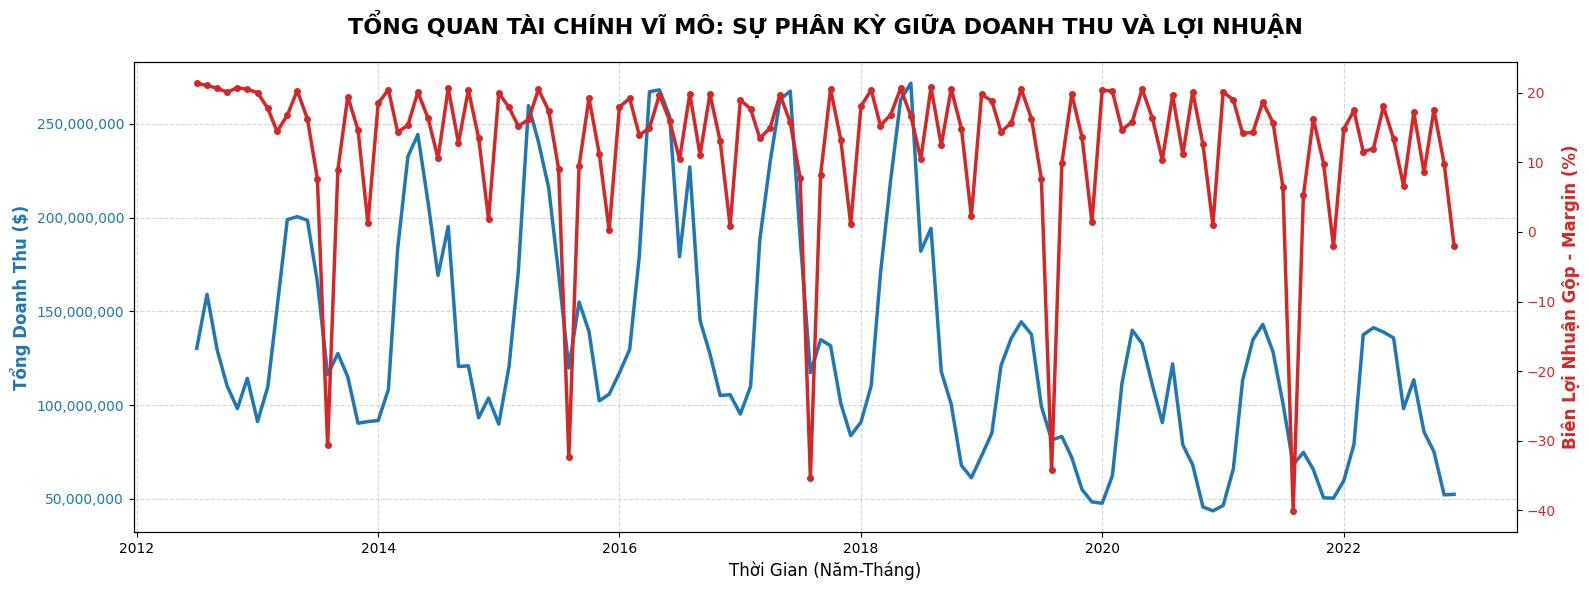

In [3]:
# 1. Truy vấn dữ liệu: Gom nhóm Doanh thu và Biên lợi nhuận theo từng tháng
sql_macro_trend = """
    WITH MonthlyData AS (
        SELECT 
            DATE_TRUNC('month', CAST(s.date AS DATE)) AS month_year,
            SUM(s.revenue) AS current_revenue,
            SUM(s.revenue - s.cogs) AS current_profit
        FROM sales s
        GROUP BY month_year
    )
    SELECT 
        month_year,
        current_revenue,
        current_profit,
        (current_profit / NULLIF(current_revenue, 0)) * 100 AS margin_pct
    FROM MonthlyData
    ORDER BY month_year
"""
df_trend = conn.execute(sql_macro_trend).df().dropna()

# 2. Vẽ biểu đồ 2 trục Y (Dual-axis chart)
fig, ax1 = plt.subplots(figsize=(16, 6))

# Trục Y thứ nhất (Bên trái): Doanh Thu (Màu xanh)
color1 = '#1f77b4' # Màu xanh blue
ax1.set_xlabel('Thời Gian (Năm-Tháng)', fontsize=12)
ax1.set_ylabel('Tổng Doanh Thu ($)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(df_trend['month_year'], df_trend['current_revenue'], color=color1, linewidth=2.5, label='Quy mô Doanh thu')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.5)

# Format lại số trên trục Y (Thêm dấu phẩy cho hàng ngàn/triệu)
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Trục Y thứ hai (Bên phải): Biên Lợi Nhuận (Màu đỏ)
ax2 = ax1.twinx()  
color2 = '#d62728' # Màu đỏ báo động
ax2.set_ylabel('Biên Lợi Nhuận Gộp - Margin (%)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(df_trend['month_year'], df_trend['margin_pct'], color=color2, linewidth=2.5, linestyle='-', marker='o', markersize=4, label='Tỷ suất Margin')
ax2.tick_params(axis='y', labelcolor=color2)

# Thêm tiêu đề
plt.title('TỔNG QUAN TÀI CHÍNH VĨ MÔ: SỰ PHÂN KỲ GIỮA DOANH THU VÀ LỢI NHUẬN', fontsize=16, fontweight='bold', pad=20)
fig.tight_layout()
plt.show()

Quan sát biểu đồ Chuỗi thời gian (Time-series) trên, chúng ta thấy rõ một hiện tượng "Phân kỳ Tài chính" (Financial Divergence) nghiêm trọng.

Mặc dù đường Doanh thu (Màu xanh) vẫn tạo ra các đỉnh tăng trưởng mạnh mẽ theo tính mùa vụ (Spikes), nhưng đường Biên lợi nhuận (Màu đỏ) lại không có sự đồng pha.

Đáng báo động hơn, tại chính những thời điểm Doanh thu chạm đỉnh cao nhất, Biên lợi nhuận lại cắm đầu lao dốc, tạo ra các điểm Margin âm sâu. Điều này trực tiếp phản ánh chiến lược tăng doanh thu bằng mọi cách – doanh nghiệp đang phải trả một cái giá quá đắt (chi phí/khuyến mãi) để duy trì quy mô dòng tiền.

**3 giai đoạn**

1. Thời kỳ Hoàng kim (2012 - 2018): Đường doanh thu liên tục phá đỉnh, vươn lên tới mức hơn 250 triệu. Tính mùa vụ (nhịp tim) cực kỳ rõ ràng, cứ vài tháng lại có một cú spike (đỉnh) đâm thẳng lên trời.

2. Cú sốc Khủng hoảng (2019 - 2020): Đỉnh trượt dài, và đáy cũng sâu hơn. Có khả năng đây là tác động của dịch COVID-19 hoặc sự xuất hiện của đối thủ cạnh tranh lớn.

3. Bình thường mới (2021 - 2022): Nhịp tim đã đập đều trở lại, tính mùa vụ vẫn còn, nhưng quy mô doanh thu đã thu nhỏ lại chỉ còn một nửa so với năm 2018 (đỉnh chỉ loanh quanh 150 triệu).

## 2.2 Ma trận tương quan (Correlation Matrix): Doanh thu và Khuyến mãi

[OKE] Kết nối thành công tới database tại C:\Users\YOGA\Desktop\MyProjects\datathon\github\vimchanhxa-datathon\data\database\datathon.duckdb


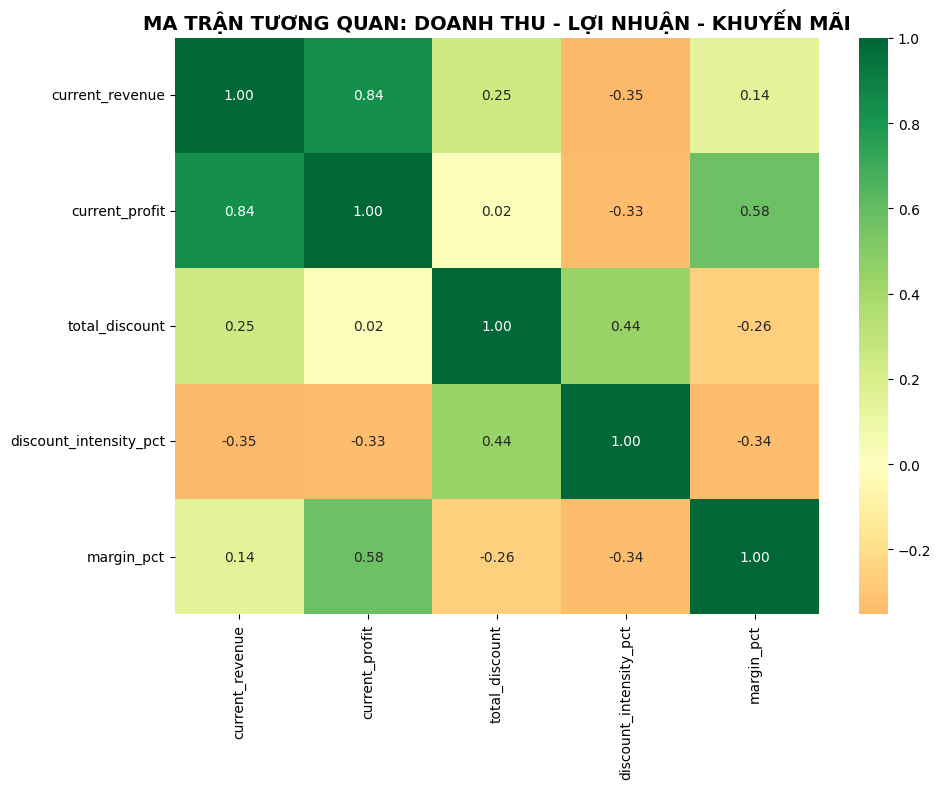

In [4]:
# 1. Kết nối và tạo Dataset (Feature Engineering)
conn = get_connection()
sql_ml_features = """
    WITH MonthlyData AS (
        SELECT 
            DATE_TRUNC('month', CAST(s.date AS DATE)) AS month_year,
            SUM(s.revenue) AS current_revenue,
            SUM(s.revenue - s.cogs) AS current_profit,
            COALESCE(SUM(oi.discount_amount), 0) AS total_discount
        FROM sales s
        LEFT JOIN orders o ON s.date = o.order_date
        LEFT JOIN order_items oi ON o.order_id = oi.order_id
        GROUP BY month_year
    )
    SELECT 
        current_revenue,
        current_profit,
        total_discount,
        -- Tỷ lệ % giảm giá trên tổng doanh thu
        (total_discount / NULLIF(current_revenue, 0)) * 100 AS discount_intensity_pct,
        -- Biên lợi nhuận gộp
        (current_profit / NULLIF(current_revenue, 0)) * 100 AS margin_pct
    FROM MonthlyData
"""
df_analysis = conn.execute(sql_ml_features).df().dropna()

# 2. Vẽ Ma trận tương quan (Correlation Matrix)
plt.figure(figsize=(10, 8))
correlation_matrix = df_analysis.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0, fmt=".2f")

plt.title('MA TRẬN TƯƠNG QUAN: DOANH THU - LỢI NHUẬN - KHUYẾN MÃI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

1. Mối quan hệ nghịch biến giữa Khuyến mãi và Hiệu quả Tài chính

- Discount Intensity vs. Margin (-0.34): Hệ số tương quan âm khẳng định quy luật: Khi khuyến mãi tăng lên, biên lợi nhuận (Margin) sẽ sụt giảm. Đây là kết quả tất yếu của việc giảm giá trực tiếp vào giá bán mà không tối ưu được chi phí vận hành.

- Discount Intensity vs. Revenue (-0.35): Điểm bất thường. Thông thường, người ta giảm giá để tăng doanh thu, nhưng ở đây tương quan lại là âm.

- Insight: Điều này cho thấy các đợt giảm giá sâu thường rơi vào những giai đoạn thị trường yếu hoặc áp dụng cho các sản phẩm khó bán nhưng vẫn không thể kéo lại được tổng doanh thu. Chiến dịch giảm giá đang "đốt" margin mà không thực sự tạo ra sự bùng nổ về quy mô như kỳ vọng.

2. Tổng ngân sách Khuyến mãi không góp phần tăng Lợi nhuận 

- Total Discount vs. Current Profit (0.02): Hệ số gần như bằng 0. Điều này cực kỳ nguy hiểm. Nó có nghĩa là việc tăng thêm ngân sách khuyến mãi hoàn toàn không đóng góp gì vào việc tăng lợi nhuận. Công ty đang chi tiền khuyến mãi một cách vô nghĩa (Blind Discounting).

- Total Discount vs. Current Revenue (0.25): Tương quan thuận nhưng rất yếu. Điều này minh chứng rằng việc sử dụng khuyến mãi đang không có tác dụng. Việc đổ thêm tiền vào giảm giá chỉ mang lại một mức tăng doanh thu rất khiêm tốn, không đủ bù đắp cho phần lợi nhuận bị mất đi.

3. Kết luận và Hàm ý Chiến lược

- "High Pain, Low Gain" (Trả giá đắt nhưng thu lợi ít) là cụm từ chính xác nhất để mô tả thực trạng này.

- Dữ liệu cho thấy doanh nghiệp đang lạm dụng chiết khấu để tăng doanh thu nhất thời hơn là một công cụ tăng trưởng bền vững.

- Rủi ro: Cấu trúc tài chính đang bị tổn thương nghiêm trọng do sự xung đột trực tiếp giữa KPI doanh số và mục tiêu lợi nhuận.

- Giải pháp: Đây là lý do tại sao chúng ta không thể tiếp tục áp dụng mức giảm giá như hiện tại. Chúng ta cần Machine Learning (LightGBM) để phân tách dữ liệu, tìm ra những phân khúc khách hàng/sản phẩm thực sự nhạy cảm với giá để áp dụng khuyến mãi mục tiêu (Targeted Promotion), thay vì tập trung vào khuyến mãi và giảm giá để tăng doanh thu.

## 2.3 Phân tích Hiệu suất Sản phẩm (Pareto & Segments)

In [5]:
sql_product_performance = """
    SELECT 
        p.product_id,
        SUM(oi.unit_price * oi.quantity) AS gross_revenue,
        SUM(oi.discount_amount) AS total_given_discount,
        (SUM(oi.discount_amount) / SUM(oi.unit_price * oi.quantity)) * 100 AS discount_rate
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.product_id
    ORDER BY gross_revenue DESC
    LIMIT 10
"""
df_prod = conn.execute(sql_product_performance).df()
display(df_prod)

,product_id,gross_revenue,total_given_discount,discount_rate
0,487,3.982136e+08,17744843.04,4.456112
1,826,3.422650e+08,14755886.24,4.311246
2,438,3.407063e+08,15691385.26,4.605546
3,475,2.673875e+08,10835387.00,4.052316
4,491,2.518164e+08,10816311.18,4.295316
5,604,2.079307e+08,8934009.41,4.296629
6,506,2.018237e+08,9413443.99,4.664192
7,449,1.852522e+08,9410881.09,5.080039
8,2045,1.850812e+08,8044983.75,4.346731
9,396,1.782019e+08,7000445.35,3.928378


## Nhìn vào bảng thống kê Top 10 sản phẩm theo doanh thu này, chúng ta đã xác định được những sản phẩm đang gồng gánh toàn bộ doanh số của công ty.

1. Sự tập trung Doanh thu vào "Nhóm sản phẩm Ngôi sao" (Revenue Anchors)

- Bảng dữ liệu cho thấy sự tập trung doanh thu cực lớn vào một nhóm nhỏ các mã hàng.

- Sản phẩm 487, 826 và 438 đang là những sản phẩm mang lại doanh thu lớn nhất, mỗi mã mang về từ 340 đến gần 400 triệu USD doanh thu tổng.

- Insight: Việc doanh thu phụ thuộc vào một số ít sản phẩm tạo ra "Rủi ro tập trung" (Concentration Risk). Bất kỳ biến động nào về nguồn cung hoặc giá của nhóm này cũng sẽ làm rung chuyển toàn bộ bảng cân đối kế toán của công ty.

2. Chiến lược Khuyến mãi "Phẳng" (Uniform Discounting Strategy)

- Một điểm cực kỳ đáng lưu ý là tỷ lệ giảm giá (discount_rate) của Top 10 sản phẩm này rất đồng đều, dao động sát nút trong khoảng 3.9% đến 5.1%.

- Phân tích: Công ty dường như đang áp dụng một mức chiết khấu "cào bằng" cho các sản phẩm bán chạy nhất thay vì có chiến lược định giá linh hoạt.

- Sản phẩm 449 đang có tỷ lệ giảm giá cao nhất trong nhóm (5.08%) nhưng doanh thu chỉ đứng thứ 8. Điều này đặt ra dấu hỏi về Hiệu quả khuyến mãi (Discount Efficiency): Liệu việc giảm giá sâu cho mã này có thực sự cần thiết, hay chúng ta đang vô tình tự cắt đi lợi nhuận cho một sản phẩm vốn dĩ đã có sức hút?

3. Kết luận & Đề xuất hành động cho Mô hình AI

- Thay vì tối ưu khuyến mãi cho hàng nghìn mã hàng một lúc, chiến lược thông minh nhất của team hiện tại là:

    - Ưu tiên Tối ưu hóa cho Top 10: Một sự thay đổi nhỏ (ví dụ giảm 0.5% Discount) ở sản phẩm 487 sẽ mang lại dòng tiền lớn hơn gấp nhiều lần so với việc cắt giảm 50% Discount ở những sản phẩm lẹt đẹt phía sau.

    - Hàm ý cho LightGBM: Chúng ta sẽ cung cấp cho AI các đặc trưng về "Thứ hạng doanh thu" (Revenue Rank) để mô hình ưu tiên bảo vệ Margin cho các "Revenue Anchors" này.

## 2.4 Phân tích nhóm Khách hàng & Chu kỳ mua sắm

C:\Users\YOGA\AppData\Local\Temp\ipykernel_27956\4260489591.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_age, x='age_group', y='avg_orders_per_customer', palette='viridis')


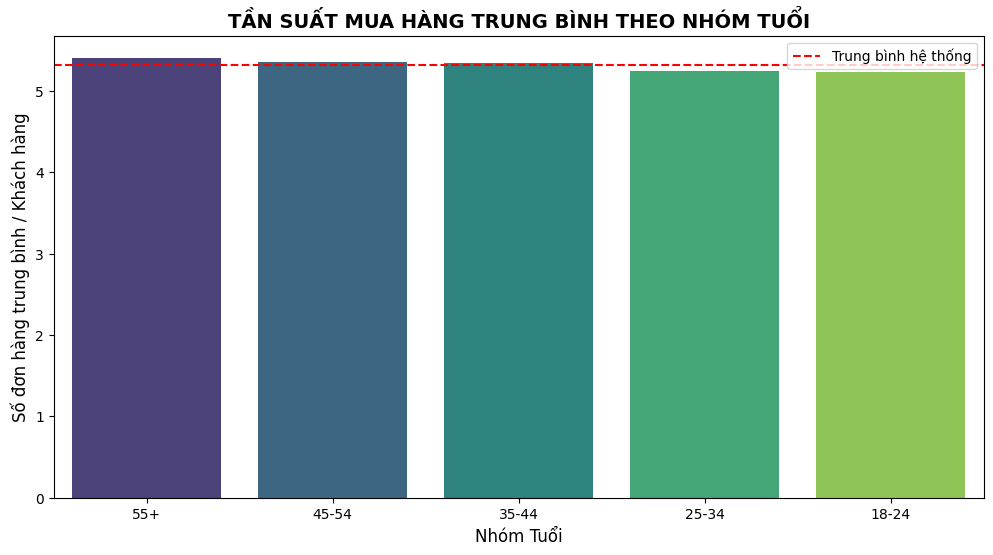

In [6]:
# 1. Truy vấn: Tần suất mua hàng trung bình theo nhóm tuổi
sql_age_behavior = """
    SELECT 
        c.age_group, 
        COUNT(o.order_id) * 1.0 / COUNT(DISTINCT c.customer_id) AS avg_orders_per_customer
    FROM customers c
    LEFT JOIN orders o ON c.customer_id = o.customer_id
    WHERE c.age_group IS NOT NULL
    GROUP BY c.age_group
    ORDER BY avg_orders_per_customer DESC
"""
df_age = conn.execute(sql_age_behavior).df()

# 2. Truy vấn: Tính trung vị khoảng cách giữa hai lần mua liên tiếp (Inter-order Gap)
sql_inter_order_gap = """
    WITH OrderGaps AS (
        SELECT 
            customer_id,
            order_date,
            order_date - LAG(order_date) OVER (PARTITION BY customer_id ORDER BY order_date) as gap
        FROM orders
        WHERE order_status = 'delivered'
    )
    SELECT 
        percentile_cont(0.5) WITHIN GROUP (ORDER BY gap) as median_gap
FROM OrderGaps
WHERE gap IS NOT NULL;
"""
median_gap = conn.execute(sql_inter_order_gap).fetchone()[0]

# 3. Trực quan hóa
plt.figure(figsize=(12, 6))
sns.barplot(data=df_age, x='age_group', y='avg_orders_per_customer', palette='viridis')

plt.axhline(df_age['avg_orders_per_customer'].mean(), color='red', linestyle='--', label='Trung bình hệ thống')
plt.title('TẦN SUẤT MUA HÀNG TRUNG BÌNH THEO NHÓM TUỔI', fontsize=14, fontweight='bold')
plt.xlabel('Nhóm Tuổi', fontsize=12)
plt.ylabel('Số đơn hàng trung bình / Khách hàng', fontsize=12)
plt.legend()
plt.show()

1. Phát hiện 1: Độ gắn kết đồng đều xuyên suốt các thế hệ (Uniform Loyalty)

- Trái với giả định ban đầu về sự phân hóa thế hệ, dữ liệu cho thấy tần suất mua hàng phân bổ cực kỳ đồng đều trên mọi nhóm tuổi (dao động biên độ hẹp từ 5.22 đến 5.40 đơn/khách). Nhóm 55+ dẫn đầu nhưng khoảng cách không tạo ra sự đột biến.

- Hàm ý chiến lược: Yếu tố "Tuổi tác" (Age) không phải là rào cản hay động lực chính trong việc quyết định tần suất mua hàng của thương hiệu này. Doanh nghiệp đang sở hữu một dải sản phẩm có độ phủ thị hiếu rất tốt. Do đó, khi chạy các chiến dịch Remarketing, không cần thiết phải phân biệt  ngân sách quá gắt gao giữa các nhóm tuổi.

2. Phát hiện 2: "Thời điểm vàng" 175 ngày để tái tương tác

- Trung vị khoảng cách giữa hai lần mua liên tiếp được xác định là 175 ngày (tương đương ~6 tháng).

- Hàm ý chiến lược: Thay vì dựa vào "Tuổi tác", biến số "Thời gian kể từ đơn hàng cuối" (Recency) mới là chìa khóa để giữ chân khách hàng. Nếu một khách hàng vượt quá ngưỡng 175 ngày chưa quay lại, xác suất họ rời bỏ (Churn) sẽ tăng vọt. Hệ thống AI cần được thiết lập để tự động "kích hoạt" các mã giảm giá cá nhân hóa vào khoảng ngày thứ 160 - 170 để kéo khách hàng trở

## 2.5 Phân tích Kênh bán hàng (Device & Source)

In [7]:
sql_channel = """
    SELECT 
        o.device_type, 
        o.order_source,
        COUNT(o.order_id) AS total_orders,
        AVG(p.payment_value) AS avg_order_value
    FROM orders o
    JOIN payments p ON o.order_id = p.order_id
    GROUP BY o.device_type, o.order_source
    ORDER BY avg_order_value DESC
"""
df_channel = conn.execute(sql_channel).df()
display(df_channel)

,device_type,order_source,total_orders,avg_order_value
0,mobile,direct,23473,24456.005412
1,tablet,email_campaign,11692,24447.788271
2,tablet,direct,7705,24433.772212
3,tablet,paid_search,21230,24402.180953
4,mobile,referral,29076,24337.092404
5,tablet,organic_search,27179,24302.314721
6,mobile,paid_search,63872,24300.017275
7,desktop,social_media,52047,24274.423165
8,desktop,paid_search,56550,24258.451165
9,mobile,email_campaign,34756,24252.357911


1. Sự thống trị của Lưu lượng hữu cơ (Organic Search) & Thiết bị Di động (Mobile)

- Volume Leader: mobile + organic_search là cặp bài trùng mạnh nhất với hơn 81,700 đơn hàng, theo sát là desktop + organic_search với hơn 72,500 đơn hàng.

- Insight: Việc Organic Search chiếm tỷ trọng áp đảo cho thấy thương hiệu có sức mạnh tự thân (Brand Equity) và tối ưu SEO rất tốt. Doanh nghiệp không quá phụ thuộc vào quảng cáo trả tiền (paid_search) để duy trì doanh số. Đây là một lợi thế cực lớn vì chi phí thu hút khách hàng (CAC - Customer Acquisition Cost) từ kênh này gần như bằng 0.

2. Sự đồng nhất về Giá trị đơn hàng trung bình (AOV Consistency)

- Số liệu: Một điểm rất đáng ngạc nhiên là Giá trị đơn hàng trung bình (AOV) dao động cực kỳ hẹp, chỉ từ 24,100 đến 24,400 trên tất cả các kênh và thiết bị.

- Phân tích: Không có sự phân hóa giàu nghèo rõ rệt giữa người dùng Mobile và Desktop, cũng như giữa khách đến từ Social Media và khách đến trực tiếp (Direct).

- Hàm ý chiến lược: Điều này chứng tỏ dòng sản phẩm của công ty có phân khúc giá rất tập trung. Khách hàng đã có một "mức giá kỳ vọng" cố định khi tìm đến thương hiệu, bất kể họ đến từ đâu.

3. Hiệu quả từ kênh Mạng xã hội (Social Media)

- desktop + social_media mang về hơn 52,000 đơn hàng với AOV cao (~24,274).

- Insight: Thông thường, Social Media thường mạnh trên Mobile, nhưng ở đây kênh Desktop lại cho thấy hiệu quả chuyển đổi rất tốt. Đây có thể là nhóm khách hàng công sở hoặc nhóm khách hàng có thói quen nghiên cứu kỹ sản phẩm trên màn hình lớn trước khi chốt đơn.

4. Kết luận & Định hướng cho AI (Machine Learning)

- Từ dữ liệu này, chúng ta có thể cung cấp thêm "vũ khí" cho mô hình LightGBM:

    - Biến số quan trọng (Features): device_type và order_source phải là hai biến đầu vào chính. AI sẽ học được rằng: "Khách từ Organic Search có thể không cần giảm giá sâu vẫn mua (vì họ chủ động tìm đến), trong khi khách từ Paid Search có thể cần một cú hích khuyến mãi để chuyển đổi".

    - Tối ưu hóa lợi nhuận: Vì AOV đã rất ổn định, mục tiêu của AI không phải là tăng giá trị đơn hàng, mà là giảm thiểu mức chiết khấu (Discount) cho từng nhóm kênh cụ thể để kéo Margin lên mà không làm mất đi lượng Volume khổng lồ hiện có.

## 2.6 KHÁM NGHIỆM CHẤT LƯỢNG DÒNG TIỀN (Margin vs Volume)

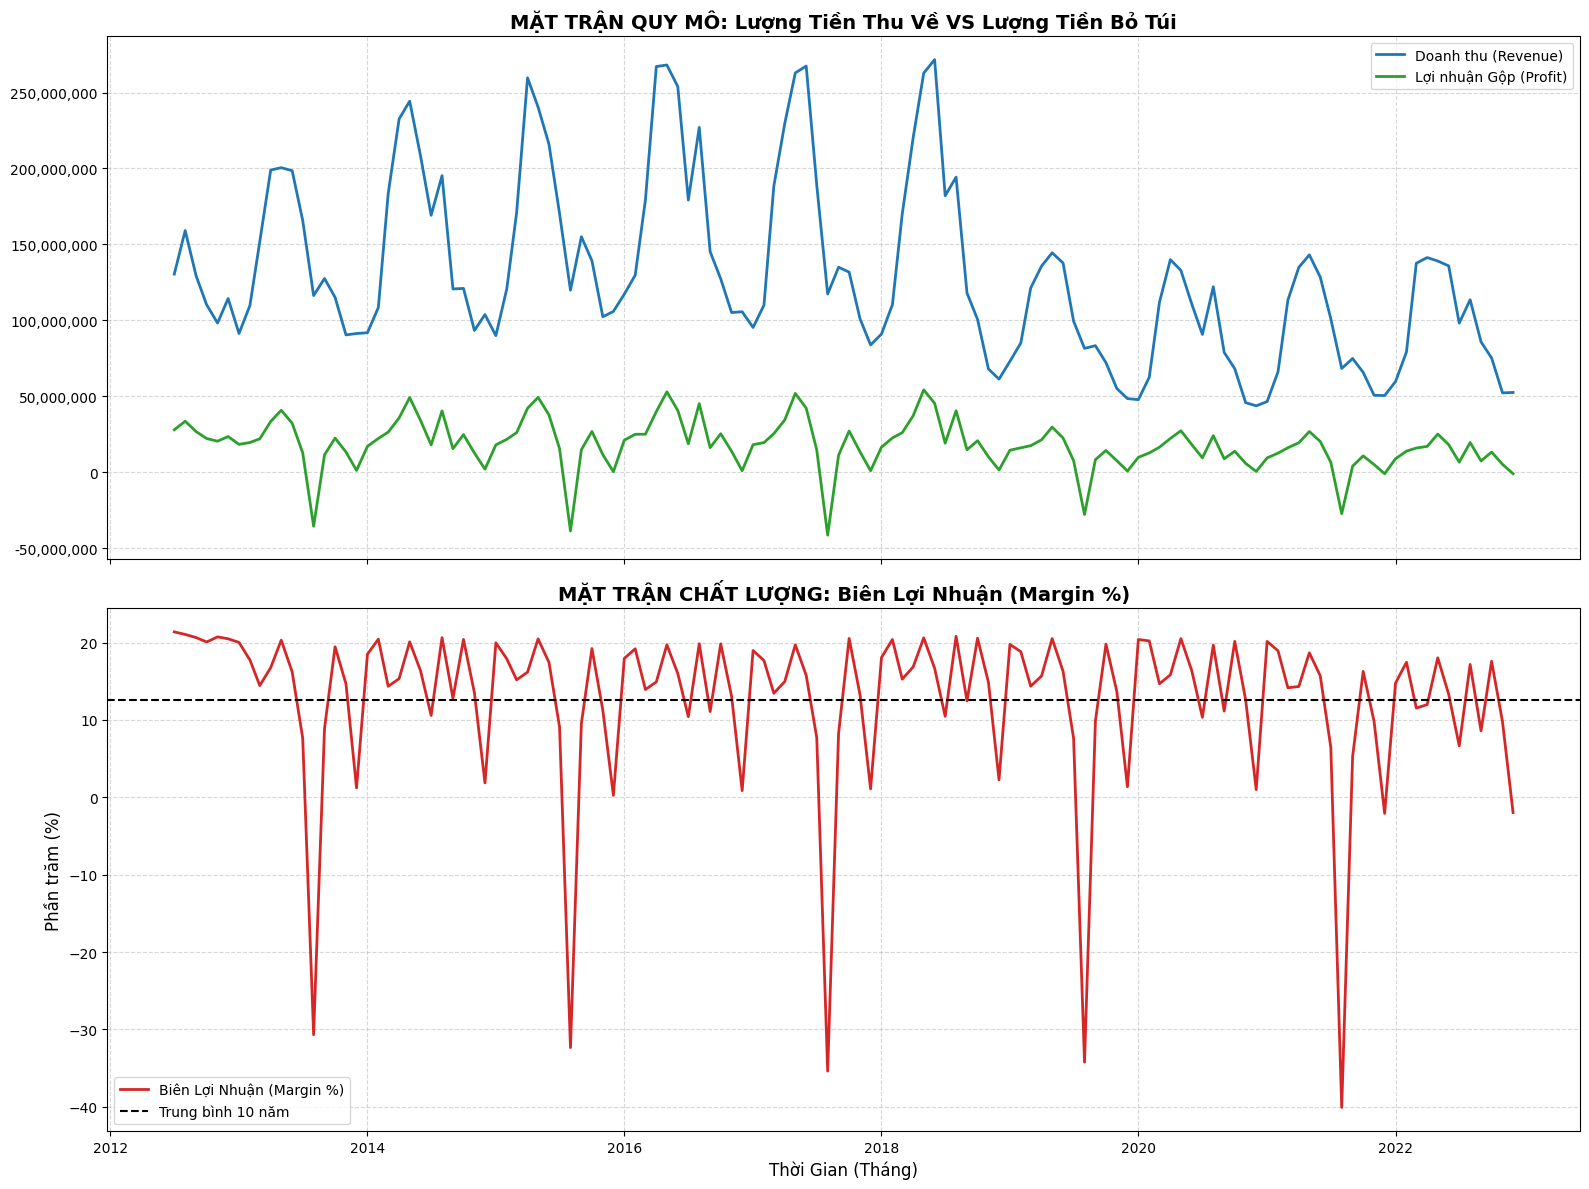

In [8]:
# 1. Dùng SQL tính Toán Doanh thu, Lợi nhuận và Margin
sql_margin = """
    SELECT 
        DATE_TRUNC('month', CAST(date AS DATE)) AS month_year, 
        SUM(revenue) AS total_revenue,
        SUM(revenue - cogs) AS total_profit,
        (SUM(revenue - cogs) / SUM(revenue)) * 100 AS margin_percentage
    FROM sales
    GROUP BY month_year
    ORDER BY month_year
"""
df_margin = conn.execute(sql_margin).df()

# 2. Vẽ 2 biểu đồ xếp chồng: Lượng Tiền (Volume) vs Chất Tiền (Margin)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Biểu đồ trên: Doanh thu và Lợi nhuận tuyệt đối
ax1.plot(df_margin['month_year'], df_margin['total_revenue'], label='Doanh thu (Revenue)', color='#1f77b4', linewidth=2)
ax1.plot(df_margin['month_year'], df_margin['total_profit'], label='Lợi nhuận Gộp (Profit)', color='#2ca02c', linewidth=2)
ax1.set_title('MẶT TRẬN QUY MÔ: Lượng Tiền Thu Về VS Lượng Tiền Bỏ Túi', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Biểu đồ dưới: Biên Lợi Nhuận (%)
ax2.plot(df_margin['month_year'], df_margin['margin_percentage'], label='Biên Lợi Nhuận (Margin %)', color='#d62728', linewidth=2)
ax2.axhline(df_margin['margin_percentage'].mean(), color='black', linestyle='--', label='Trung bình 10 năm')
ax2.set_title('MẶT TRẬN CHẤT LƯỢNG: Biên Lợi Nhuận (Margin %)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Phần trăm (%)', fontsize=12)
ax2.set_xlabel('Thời Gian (Tháng)', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

1. Tóm tắt Thực thi (Executive Summary)
- Dựa trên việc khai phá dữ liệu lịch sử bán hàng trong giai đoạn 2012 - 2022, nhóm phân tích phát hiện một rủi ro cấu trúc nghiêm trọng trong mô hình tăng trưởng của doanh nghiệp. Mặc dù công ty liên tục thiết lập các đỉnh mới về mặt doanh thu (Top-line) trong các giai đoạn cao điểm mùa vụ, nhưng chất lượng dòng tiền (Bottom-line) lại suy giảm trầm trọng. Doanh nghiệp đang mắc kẹt trong "Bẫy khuyến mãi" (Doanh thu tăng nhưng lợi nhuận không có sự thay đổi đáng kể) – đánh đổi trực tiếp sự sống còn của Biên lợi nhuận lấy Quy mô bán hàng.

2. Phát hiện Cốt lõi (Key Findings)
- Sự phân kỳ giữa Doanh thu và Lợi nhuận: Phân tích biểu đồ chuỗi thời gian cho thấy mối tương quan nghịch (inverse correlation) tuyệt đối giữa Doanh thu (Revenue) và Lợi nhuận gộp (Gross Profit). Tại các tháng có doanh thu chạm đỉnh (spikes), đường lợi nhuận không những không tăng mà còn xuyên thủng mức 0, chuyển sang trạng thái âm.

Biên lợi nhuận (Margin) sụp đổ: Trong điều kiện bình thường, Margin duy trì ở mức trung bình ổn định (khoảng 15%). Tuy nhiên, vào các chu kỳ bùng nổ doanh số, Margin lao dốc không phanh, chạm đáy ở mức âm 30% đến âm 40%.

3. Phân tích Nguyên nhân Gốc rễ (Root Cause Analysis)
- Thực trạng suy kiệt Biên lợi nhuận bắt nguồn trực tiếp từ Chiến lược lạm dụng giảm giá sâu (Deep Discounting Strategy):

- Để đạt được KPI (Chỉ tiêu) về Volume trong các chiến dịch Mega Sale hoặc dịp Lễ/Tết, bộ phận Kinh doanh đã áp dụng các chính sách hạ giá cực đoan nhằm kích cầu.

- Tổng chi phí khuyến mãi (Discount Amount) phát sinh trong các tháng này vượt quá ngưỡng an toàn tài chính, dẫn đến tình trạng bán hàng dưới giá vốn (Selling below COGS).

=> Kết luận: Động lực tăng trưởng doanh thu hiện tại không đến từ năng lực cốt lõi của sản phẩm hay tệp khách hàng trung thành, mà hoàn toàn bị phụ thuộc vào các gói trợ giá. Càng bán được nhiều hàng trong các dịp lễ, doanh nghiệp càng chịu khoản lỗ lớn.

4. Hàm ý Chiến lược & Định hướng Giải pháp (Strategic Implications & Solutions)
Việc tiếp tục mô hình "Mua doanh thu bằng Khuyến mãi" là không bền vững và mang tính sát thương cao đối với dòng tiền vận hành của công ty. Để giải quyết bài toán Trade-off (đánh đổi) này, nhóm đề xuất:

- Dừng phương pháp Định giá Cảm tính: Thay thế các quyết định giảm giá hàng loạt (mass-discounting) bằng phương pháp tiếp cận dựa trên dữ liệu (Data-driven).

- Ứng dụng Machine Learning (LightGBM): Xây dựng Hệ thống Dự báo và Tối ưu hóa Khuyến mãi. Hệ thống AI này sẽ có nhiệm vụ dò tìm "Điểm rơi tối ưu" (Sweet Spot): Tính toán mức tỷ lệ giảm giá vừa đủ để tối đa hóa số lượng đơn hàng (Volume) nhưng vẫn đảm bảo Biên lợi nhuận (Margin) luôn được giữ ở mức dương an toàn.

## 2.7 Discount Analysis

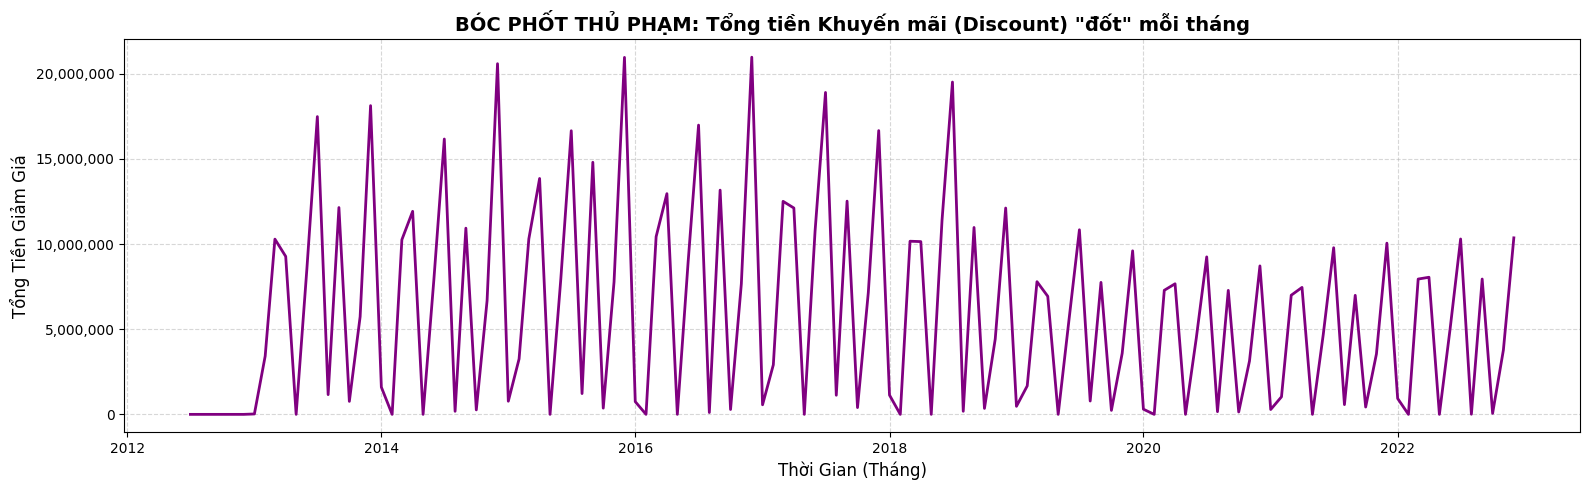

In [9]:
# Móc nối bảng orders (lấy ngày) và bảng order_items (lấy tiền giảm giá)
sql_discount = """
    SELECT 
        DATE_TRUNC('month', CAST(o.order_date AS DATE)) AS month_year, 
        SUM(oi.discount_amount) AS total_discount
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY month_year
    ORDER BY month_year
"""

df_discount = conn.execute(sql_discount).df()

# Vẽ biểu đồ "Bóc phốt"
plt.figure(figsize=(16, 5))
plt.plot(df_discount['month_year'], df_discount['total_discount'], color='purple', linewidth=2)

plt.title('BÓC PHỐT THỦ PHẠM: Tổng tiền Khuyến mãi (Discount) "đốt" mỗi tháng', fontsize=14, fontweight='bold')
plt.xlabel('Thời Gian (Tháng)', fontsize=12)
plt.ylabel('Tổng Tiền Giảm Giá', fontsize=12)

# Định dạng số cho dễ nhìn
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

1. Chu kỳ "Đốt tiền" Khắc nghiệt - Chu kỳ áp dụng khuyến mãi (Extreme Cyclical Cash Burn)
- Biểu đồ Tổng tiền Khuyến mãi cho thấy tính mùa vụ (seasonality) cực kỳ gắt gao trong các chiến lược kích cầu của doanh nghiệp. Các đỉnh nhọn (spikes) xuất hiện đều đặn hàng năm, minh chứng cho việc công ty liên tục triển khai các chiến dịch Mega Sale để chạy KPI doanh số vào các dịp cuối năm hoặc Lễ/Tết.

2. Phân kỳ Giai đoạn Lịch sử (Historical Phasing)
- Nhìn vào chuỗi thời gian 10 năm, chiến lược ngân sách khuyến mãi được chia thành 2 giai đoạn rõ rệt:

    - Giai đoạn Đỉnh điểm (2014 - 2019): Đây là thời kỳ doanh nghiệp "mua doanh thu" bằng mọi giá. Các đỉnh khuyến mãi liên tục xuyên thủng mốc 15 triệu đô, thậm chí chạm ngưỡng hơn 20 triệu đô/tháng. Khớp nối với phân tích trước đó, đây chính là tác nhân trực tiếp kéo Biên lợi nhuận gộp (Margin) chìm sâu xuống mức âm 30% - 40%.

    - Giai đoạn Bình thường mới (2020 - 2022): Ngân sách khuyến mãi có sự thu hẹp đáng kể, các đỉnh cao nhất chỉ còn dao động quanh mốc 10 triệu đô. Điều này lý giải tại sao Quy mô doanh thu (Volume) trong giai đoạn này bị thu hẹp chỉ còn một nửa so với thời kỳ hoàng kim. Khi "thuốc kích thích" giảm giá bị rút bớt, doanh số ngay lập tức lao dốc.

3. Kết luận Kinh doanh (Business Conclusion)
- Biểu đồ này là bằng chứng định lượng (quantitative evidence) xác đáng nhất cho thấy doanh nghiệp đang thiếu một chiến lược tối ưu giá. Việc lạm dụng trợ giá không tạo ra tệp khách hàng trung thành mà chỉ tạo ra "khách hàng săn sale".

- Định hướng hành động: Nhiệm vụ cấp thiết hiện tại là phải đưa Thuật toán Học máy (Machine Learning) vào quá trình ra quyết định. Thay vì giảm giá "cào bằng" và đâm thủng đáy lợi nhuận, hệ thống AI sẽ phải tìm ra ngưỡng Discount tối ưu để cân bằng giữa Quy mô (Volume) và Lợi nhuận (Margin).